In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

bonds = pd.read_csv(DATA_DIR / "bond_portfolio_data.csv")

print(bonds.shape)
display(bonds.head())

(300, 44)


,BondID,ISIN,Issuer,Sector,CreditRating,Currency,FaceValue,CouponRate,CouponFrequency,BondType,...,CallDate,IsPutable,IsFloatingRate,BenchmarkIndex,PriceChange_Up50bps,PriceChange_Dn50bps,PriceChange_Up100bps,PriceChange_Dn100bps,PriceChange_Up200bps,PriceChange_Dn200bps
0,ZTFI-0001,IN1043321819,Government of India,Government,SOV,INR,100,0.0620,2,Fixed,...,NaN,False,False,IN10YT,0.9207,-0.9098,1.8522,-1.8086,3.7480,-3.5736
1,ZTFI-0002,IN7940265423,Government of India,Government,SOV,INR,100,0.0773,2,Fixed,...,NaN,False,False,IN10YT,6.1042,-5.6378,12.6747,-10.8091,27.2150,-19.7526
2,ZTFI-0003,IN7816184959,Government of India,Government,SOV,INR,100,0.0555,2,Fixed,...,NaN,False,False,IN10YT,2.0557,-2.0040,4.1631,-3.9562,8.5332,-7.7056
3,ZTFI-0004,IN4752553419,Government of India,Government,SOV,INR,100,0.0681,2,Fixed,...,NaN,False,False,IN10YT,6.3440,-5.7961,13.2358,-11.0444,28.6631,-19.8973
4,ZTFI-0005,IN5030564139,Government of India,Government,SOV,INR,100,0.0750,2,Fixed,...,NaN,False,False,IN10YT,5.4267,-5.0533,11.2267,-9.7333,23.9468,-17.9731


In [2]:
features = [
    "CouponRate",
    "YearsToMaturity",
    "YieldToMaturity",
    "ModifiedDuration",
    "Convexity",
    "DV01_Per100Face",
    "SpreadOverBenchmark_bps",
    "OAS_bps",
    "ZSpread_bps"
]

target = "CleanPrice"

X = bonds[features]
y = bonds[target]

print(X.shape)
print(y.shape)

(300, 9)
(300,)


In [3]:
print(X.isnull().sum())
print(y.isnull().sum())

CouponRate                 0
YearsToMaturity            0
YieldToMaturity            0
ModifiedDuration           0
Convexity                  0
DV01_Per100Face            0
SpreadOverBenchmark_bps    0
OAS_bps                    0
ZSpread_bps                0
dtype: int64
0


In [4]:
X = X.fillna(X.median())

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 1.8717
RMSE: 3.6935
R² Score: 0.6549


In [8]:
model_results = pd.DataFrame({
    "Model": ["Random Forest Regressor"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2_Score": [r2]
})

display(model_results)

,Model,MAE,RMSE,R2_Score
0,Random Forest Regressor,1.871689,3.693516,0.654851


In [9]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance)

,Feature,Importance
0,CouponRate,0.444448
3,ModifiedDuration,0.197587
2,YieldToMaturity,0.098548
4,Convexity,0.085330
5,DV01_Per100Face,0.084351
1,YearsToMaturity,0.068059
8,ZSpread_bps,0.017739
7,OAS_bps,0.002457
6,SpreadOverBenchmark_bps,0.001481


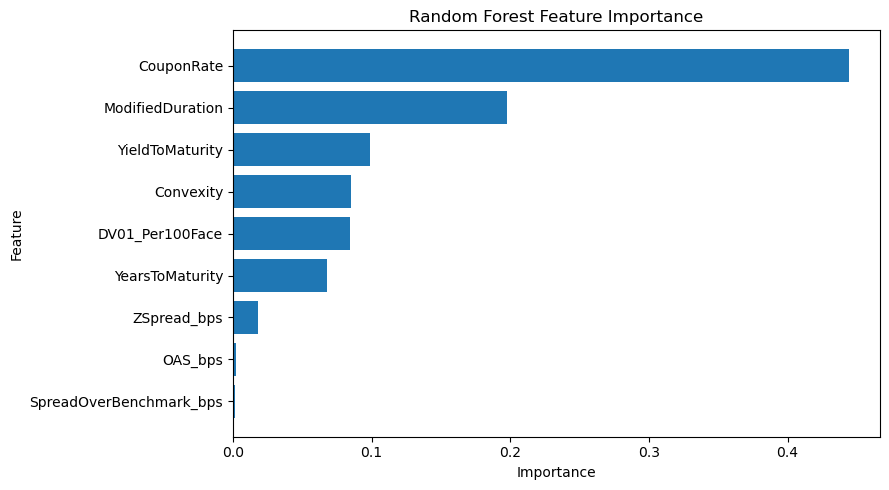

In [10]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

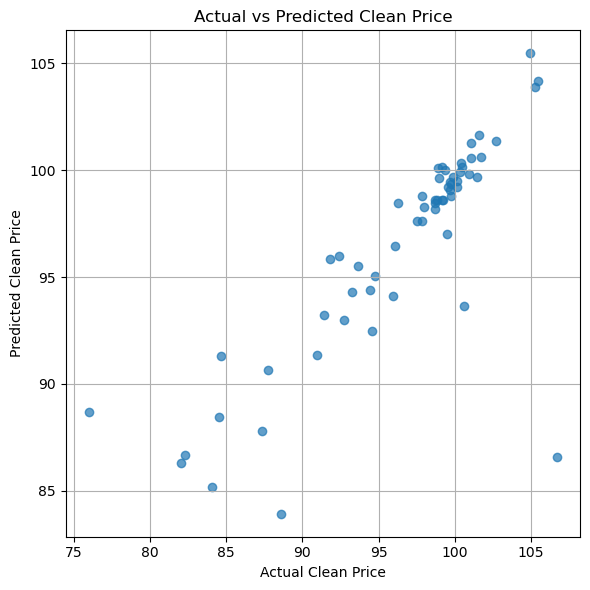

In [11]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.title("Actual vs Predicted Clean Price")
plt.xlabel("Actual Clean Price")
plt.ylabel("Predicted Clean Price")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
model_results.to_csv(REPORTS_DIR / "random_forest_results_day7.csv", index=False)
feature_importance.to_csv(REPORTS_DIR / "random_forest_feature_importance_day7.csv", index=False)

print("Day 7 Random Forest outputs saved successfully.")

Day 7 Random Forest outputs saved successfully.
